In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
# this is a project

In [8]:
cali = fetch_california_housing(as_frame=True)
df = cali.frame
np.random.seed(42)
df.iloc[np.random.randint(0,len(df),15),0]=np.nan
print("Missing values before imputation:\n",df.isnull().sum()[:3])
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df),columns=df.columns)
X = df_imputed.drop(columns=['MedHouseVal'])
y = df_imputed['MedHouseVal']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X),columns=X.columns)
print("\n Data preprocessing complete . Features scaled succesfully")
display(X_scaled.head())


Missing values before imputation:
 MedInc      15
HouseAge     0
AveRooms     0
dtype: int64

 Data preprocessing complete . Features scaled succesfully


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.345185,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332655,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.783009,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.933112,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012921,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


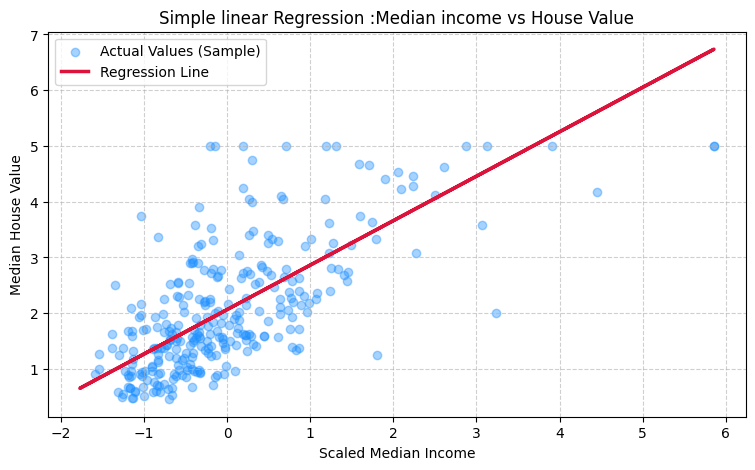

In [9]:
X_simple = X_scaled[['MedInc']]
X_train_s,X_test_s ,y_train_s,y_test_s = train_test_split(X_simple,y,test_size=0.2,random_state=42)
model_simple = LinearRegression()
model_simple.fit(X_train_s,y_train_s)
y_pred_s = model_simple.predict(X_test_s)
plt.figure(figsize=(9,5))
plt.scatter(X_test_s[:300],y_test_s[:300],alpha=0.4,color='dodgerblue',label='Actual Values (Sample)')
plt.plot(X_test_s,y_pred_s,color='crimson',linewidth=2.5,label='Regression Line')
plt.title('Simple linear Regression :Median income vs House Value')
plt.xlabel('Scaled Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.grid(True,linestyle='--',alpha =0.6)
plt.show()


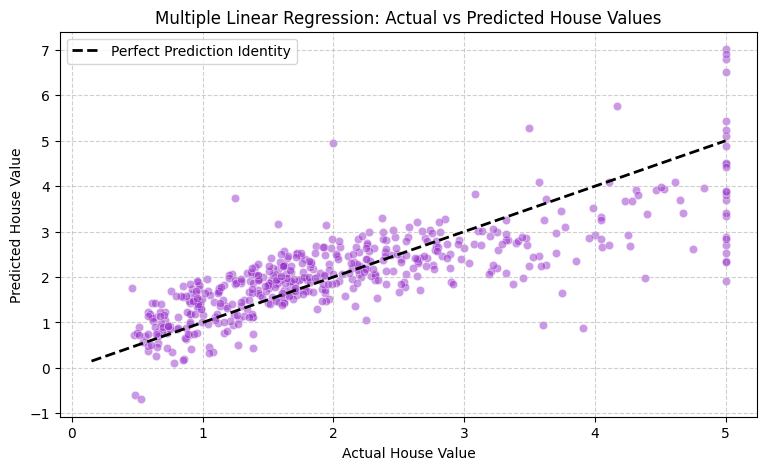

In [10]:
# Cell 4: Multiple Linear Regression (Using All Features)

# Train-Test Split using all available scaled columns
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Fit Multiple Linear Regression Model
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Predict targets for the test set
y_pred_m = model_multi.predict(X_test_m)

# Visualize Actual vs Predicted Values
plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_test_m[:500], y=y_pred_m[:500], alpha=0.5, color='darkorchid')
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'k--', lw=2, label='Perfect Prediction Identity')
plt.title('Multiple Linear Regression: Actual vs Predicted House Values')
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [11]:
# Cell 5: Evaluate Models using MSE, RMSE, and R² Score

def compute_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        "Model Type": model_name,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R² Score": round(r2, 4)
    }

# Combine performance stats into a comparison DataFrame
performance_summary = pd.DataFrame([
    compute_metrics(y_test_s, y_pred_s, "Simple Linear Regression (1 Feature)"),
    compute_metrics(y_test_m, y_pred_m, "Multiple Linear Regression (All Features)")
])

print("--- Final Model Comparison ---")
display(performance_summary)

--- Final Model Comparison ---


,Model Type,MSE,RMSE,R² Score
0,Simple Linear Regression (1 Feature),0.7091,0.8421,0.4589
1,Multiple Linear Regression (All Features),0.5558,0.7455,0.5759
